In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

# Dosyayı Colab ortamından okuma
df = pd.read_csv('df_model_final.csv')

# True/False formatındaki sütunları 1/0 formatına çevirme
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Bağımsız değişkenleri (X) ve hedef değişkeni (Target - y) ayırma
X = df.drop('Target', axis=1)
y = df['Target']

# Veriyi %80 Eğitim, %20 Test olarak bölme (stratify ile sınıf dengesini koruyarak)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu: (5636, 16)
Test seti boyutu: (1410, 16)


In [5]:
# CatBoost modelini tanımlama
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=100  # Her 100 iterasyonda bir süreci ekrana bas
)

# Modeli eğitme
print("Model eğitimi başlıyor...")
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50 # 50 adım boyunca iyileşme olmazsa eğitimi durdur (overfitting'i önler)
)

# Test seti üzerinde tahmin yapma
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Sonuçları yazdırma
print("\n--- Model Değerlendirme Sonuçları ---")
print(classification_report(y_test, y_pred))
print("ROC-AUC Skoru:", roc_auc_score(y_test, y_prob))

Model eğitimi başlıyor...
0:	test: 0.9195262	best: 0.9195262 (0)	total: 57ms	remaining: 56.9s
100:	test: 0.9716533	best: 0.9716936 (99)	total: 925ms	remaining: 8.23s
200:	test: 0.9733052	best: 0.9733052 (200)	total: 1.61s	remaining: 6.4s
300:	test: 0.9739238	best: 0.9739540 (299)	total: 1.94s	remaining: 4.51s
400:	test: 0.9744027	best: 0.9745415 (378)	total: 2.28s	remaining: 3.41s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9745415221
bestIteration = 378

Shrink model to first 379 iterations.

--- Model Değerlendirme Sonuçları ---
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       705
           1       0.90      0.94      0.92       705

    accuracy                           0.92      1410
   macro avg       0.92      0.92      0.92      1410
weighted avg       0.92      0.92      0.92      1410

ROC-AUC Skoru: 0.9745415220562347


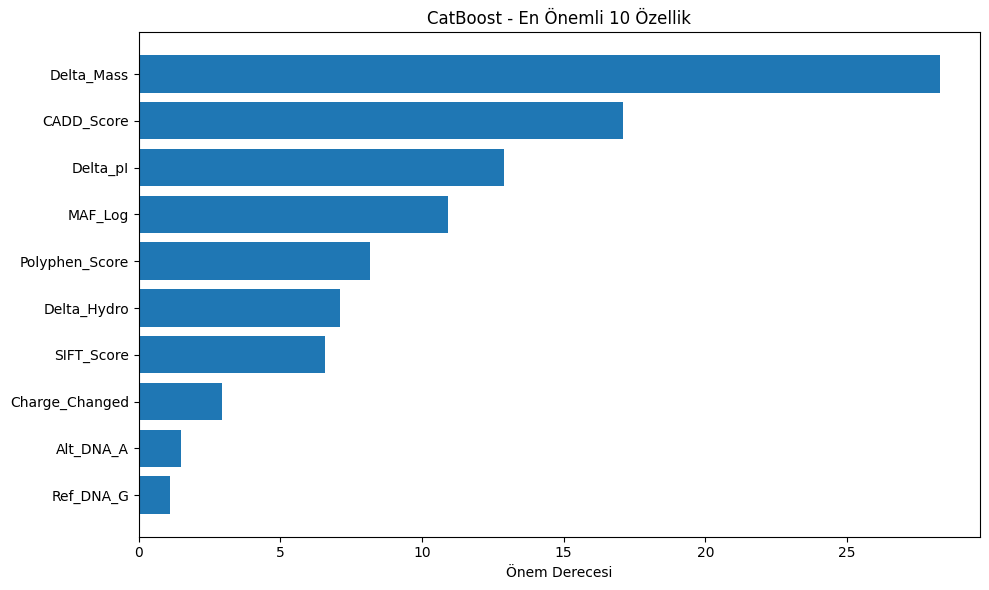

In [6]:
# En önemli 10 özelliği görselleştirme
feature_importance = model.feature_importances_
sorted_idx = feature_importance.argsort()[-10:] # En yüksek etkiye sahip son 10 özellik

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.title('CatBoost - En Önemli 10 Özellik')
plt.xlabel('Önem Derecesi')
plt.tight_layout()
plt.show()

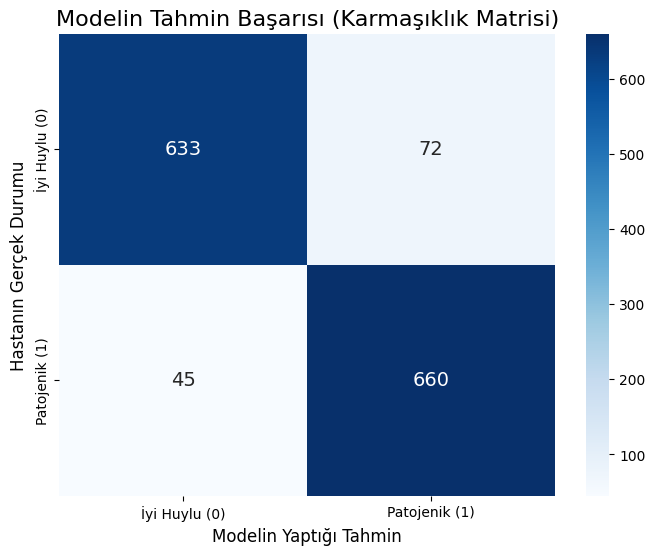

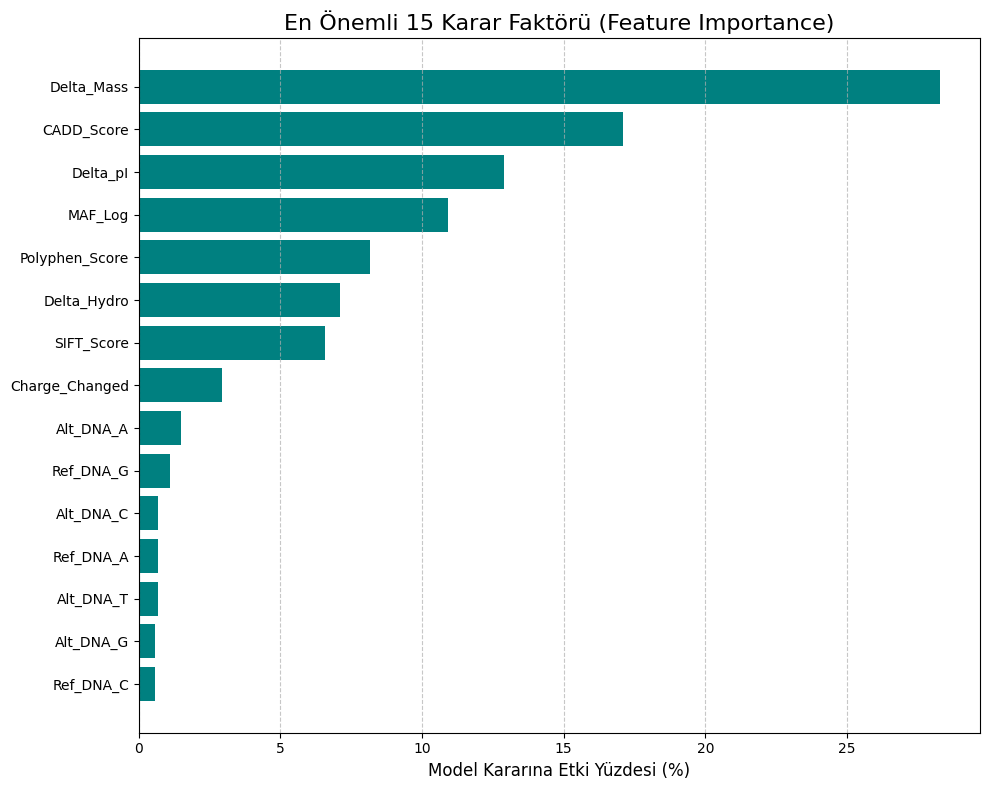

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ---------------------------------------------------------
# 1. KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX) GÖRSELLEŞTİRME
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Isı haritası (Heatmap) ile şık bir çizim
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['İyi Huylu (0)', 'Patojenik (1)'],
            yticklabels=['İyi Huylu (0)', 'Patojenik (1)'],
            annot_kws={"size": 14}) # Yazı boyutunu büyütelim

plt.title('Modelin Tahmin Başarısı (Karmaşıklık Matrisi)', fontsize=16)
plt.xlabel('Modelin Yaptığı Tahmin', fontsize=12)
plt.ylabel('Hastanın Gerçek Durumu', fontsize=12)
plt.show()

print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# 2. ÖZELLİK ÖNEMİ (FEATURE IMPORTANCE) GÖRSELLEŞTİRME
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# Modelin özellik önem derecelerini çekme
feature_importances = model.get_feature_importance()

# En önemli 15 özelliği bulup sıralayalım
top_n = 15
sorted_idx = feature_importances.argsort()[-top_n:]

# Yatay bar grafiği çizimi
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], color='teal', align='center')
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx], fontsize=10)
plt.title(f'En Önemli {top_n} Karar Faktörü (Feature Importance)', fontsize=16)
plt.xlabel('Model Kararına Etki Yüzdesi (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
# ── CELL 5 — KURULUM ──────────────────────────────────────
!pip install deap -q

import random
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from deap import base, creator, tools, algorithms
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer

f1_scorer = make_scorer(f1_score, average='macro')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Kütüphaneler yüklendi")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 3.6 MB/s eta 0:00:00
✅ Kütüphaneler yüklendi


In [13]:
# ── CELL 6 — FITNESS FONKSİYONU ───────────────────────────
def evaluate_catboost(individual):
    lr    = float(np.clip(individual[0], 0.01, 0.30))  # float() eklendi
    depth = int(np.clip(round(individual[1]), 3, 10))

    model = CatBoostClassifier(
        iterations=300,
        learning_rate=lr,
        depth=depth,
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0
    )
    score = cross_val_score(
        model, X, y, cv=cv, scoring=f1_scorer
    ).mean()
    return (score,)

In [14]:
# ── CELL 7 — GA KURULUMU ──────────────────────────────────
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_lr",    random.uniform, 0.01, 0.30)
toolbox.register("attr_depth", random.uniform, 3.0,  10.0)
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_lr, toolbox.attr_depth), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate",   evaluate_catboost)
toolbox.register("mate",       tools.cxBlend, alpha=0.5)
toolbox.register("mutate",     tools.mutGaussian, mu=0, sigma=0.05, indpb=0.5)
toolbox.register("select",     tools.selTournament, tournsize=3)

print("✅ GA toolbox hazır")

✅ GA toolbox hazır


In [15]:
# ── CELL 8 — GA ÇALIŞTIR ──────────────────────────────────
print("🧬 Genetik Algoritma başlıyor...")
print("   Optimize edilen parametreler: learning_rate, depth")
print("   Fitness fonksiyonu: 5-fold CV Makro F1")
print("─" * 50)

pop   = toolbox.population(n=20)
hof   = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max_f1", np.max)
stats.register("avg_f1", np.mean)

pop, log = algorithms.eaSimple(
    pop, toolbox,
    cxpb=0.6,
    mutpb=0.3,
    ngen=15,
    stats=stats,
    halloffame=hof,
    verbose=True
)

🧬 Genetik Algoritma başlıyor...
   Optimize edilen parametreler: learning_rate, depth
   Fitness fonksiyonu: 5-fold CV Makro F1
──────────────────────────────────────────────────
gen	nevals	max_f1  	avg_f1  
0  	20    	0.915245	0.912495
1  	16    	0.915245	0.913729
2  	16    	0.915245	0.914042
3  	11    	0.915245	0.914027
4  	12    	0.915245	0.914665
5  	18    	0.915393	0.915104
6  	16    	0.915532	0.91468 
7  	13    	0.915954	0.91441 
8  	16    	0.915962	0.915192
9  	15    	0.915962	0.914561
10 	11    	0.916385	0.915001
11 	12    	0.916385	0.915207
12 	16    	0.916385	0.914405
13 	11    	0.916385	0.915299
14 	12    	0.916385	0.915021
15 	11    	0.916385	0.915526


In [16]:
# ── CELL 9 — SONUÇLAR ─────────────────────────────────────
best       = hof[0]
best_lr    = round(float(np.clip(best[0], 0.01, 0.30)), 4)
best_depth = int(np.clip(round(best[1]), 3, 10))
best_f1    = best.fitness.values[0]

# Baseline: arkadaşın orijinal parametreleri
baseline_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
baseline_f1 = cross_val_score(
    baseline_model, X, y, cv=cv, scoring=f1_scorer
).mean()

print("\n" + "="*50)
print("📊 GA OPTİMİZASYON SONUÇLARI")
print("="*50)
print(f"  Baseline  → lr=0.0500, depth=6        | Makro F1: {baseline_f1:.4f}")
print(f"  GA Sonucu → lr={best_lr}, depth={best_depth}  | Makro F1: {best_f1:.4f}")
print(f"  İyileşme  → +{(best_f1 - baseline_f1):.4f}")
print("="*50)


📊 GA OPTİMİZASYON SONUÇLARI
  Baseline  → lr=0.0500, depth=6        | Makro F1: 0.9141
  GA Sonucu → lr=0.0805, depth=6  | Makro F1: 0.9164
  İyileşme  → +0.0023


In [17]:
# ── CELL 10 — OPTİMİZE MODEL İLE FINAL EĞİTİM ────────────
final_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=best_lr,
    depth=best_depth,
    auto_class_weights='Balanced',
    eval_metric='AUC',
    early_stopping_rounds=50,
    random_seed=42,
    verbose=100
)

final_model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test)
)

y_pred_ga  = final_model.predict(X_test)
y_prob_ga  = final_model.predict_proba(X_test)[:, 1]

print("\n--- GA ile Optimize Edilmiş CatBoost Sonuçları ---")
print(classification_report(y_test, y_pred_ga))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_ga), 4))

0:	test: 0.9195262	best: 0.9195262 (0)	total: 4.71ms	remaining: 4.7s
100:	test: 0.9729903	best: 0.9729903 (100)	total: 514ms	remaining: 4.57s
200:	test: 0.9740134	best: 0.9740838 (198)	total: 906ms	remaining: 3.6s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9741904331
bestIteration = 235

Shrink model to first 236 iterations.

--- GA ile Optimize Edilmiş CatBoost Sonuçları ---
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       705
           1       0.90      0.93      0.92       705

    accuracy                           0.91      1410
   macro avg       0.92      0.91      0.91      1410
weighted avg       0.92      0.91      0.91      1410

ROC-AUC: 0.9742
